# Logistic regression, from scratch and from scikit-learn

Lesson 3 predicted a number. This lesson predicts a **decision**: will this disk
drive fail in the next thirty days, yes or no?

The change looks small and is not. A price can be any real number, so a straight
line is a sensible thing to fit. A label is 0 or 1, and a straight line through
zeros and ones will happily predict −0.3 and 1.4, which are not answers to the
question asked.

By the end of this notebook you will have:

1. seen **why** linear regression is the wrong tool here, on a picture rather
   than by assertion,
2. built the sigmoid function that fixes it, and read a decision boundary off a
   plot,
3. seen why the cost function had to change too — squared error does not merely
   score worse, it stops pushing the model exactly where the model is most
   wrong,
4. implemented the whole thing in about fifteen lines of NumPy, and
5. recovered the coefficients that generated the data, to two decimal places.

The dataset is 8,000 disk drives with SMART telemetry — the self-monitoring
statistics real drives report. It is synthetic, and deliberately so: the
coefficients that produced the labels are written down in `disk_data.py`, so
every estimate below can be checked against the truth.

In [1]:
# Everything here ships with the course image. To run it elsewhere:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from disk_data import (FEATURES, TRUE_COEFFICIENTS, TRUE_INTERCEPT,
                       load_drives, transform_features)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

drives = load_drives()
print(f"{len(drives):,} drives, {drives['failed'].sum()} failures "
      f"({drives['failed'].mean():.1%})")
drives.head()

8,000 drives, 306 failures (3.8%)


,power_on_hours,temperature_c,reallocated_sectors,spin_retry_count,read_error_rate,seek_error_rate,failed
0,19119,36.7,3,0,0.003809,0.002836,0
1,24272,35.9,4,0,0.001295,0.004228,0
2,17296,30.4,2,1,0.001385,0.000854,0
3,15895,34.5,2,0,0.002111,0.002275,0
4,25918,34.5,4,0,0.000946,0.014577,0


## 1. What goes wrong if we just fit a line

Take one column — the number of reallocated sectors, which is the single
strongest warning a drive gives — and fit ordinary least squares to the 0/1
label, exactly as in lesson 3.

Nothing stops us. The code runs. Look at what comes out.

In [2]:
x = drives[["reallocated_sectors"]]
y = drives["failed"]

line = LinearRegression().fit(x, y)

grid = pd.DataFrame({"reallocated_sectors":
                     np.linspace(0, 34, 300)})
linear_prediction = line.predict(grid)

fitted = line.predict(x)
print(f"intercept: {line.intercept_:+.4f}   slope: {line.coef_[0]:+.5f} per sector")
print(f"a drive with 0 reallocated sectors is given {line.intercept_:+.4f}")
print(f"predictions below 0: {(fitted < 0).sum():,} of {len(x):,} drives "
      f"({(fitted < 0).mean():.0%})")
print(f"the line crosses 1 at {(1 - line.intercept_) / line.coef_[0]:.1f} sectors "
      f"(the worst drive we observe has {int(x.max().iloc[0])})")

intercept: -0.0342   slope: +0.03263 per sector
a drive with 0 reallocated sectors is given -0.0342
predictions below 0: 3,606 of 8,000 drives (45%)
the line crosses 1 at 31.7 sectors (the worst drive we observe has 28)


Read the third line: **3,606 of the 8,000 drives — 45% of the fleet — are given
a negative probability of failing.** Not a small one. A negative one.

The healthiest drives get the most absurd answers, because the fitted line has
to pass low enough on the left to reach the failures on the right. And the
absurdity is not confined to one end: extend the line to 32 reallocated sectors
and it predicts a probability above 1. No drive in this fleet is that bad — the
worst has 28 — but the model is one slightly worse drive away from claiming a
certainty greater than certain.

**This is not a defect that better fitting would remove.** A straight line is
unbounded, and probabilities are bounded; no choice of slope and intercept
reconciles the two. The fix has to change the shape of the function, not its
parameters.

So we pass the line through something that squashes any real number into
$(0, 1)$. That something is the **sigmoid**, and the picture shows the two side
by side.

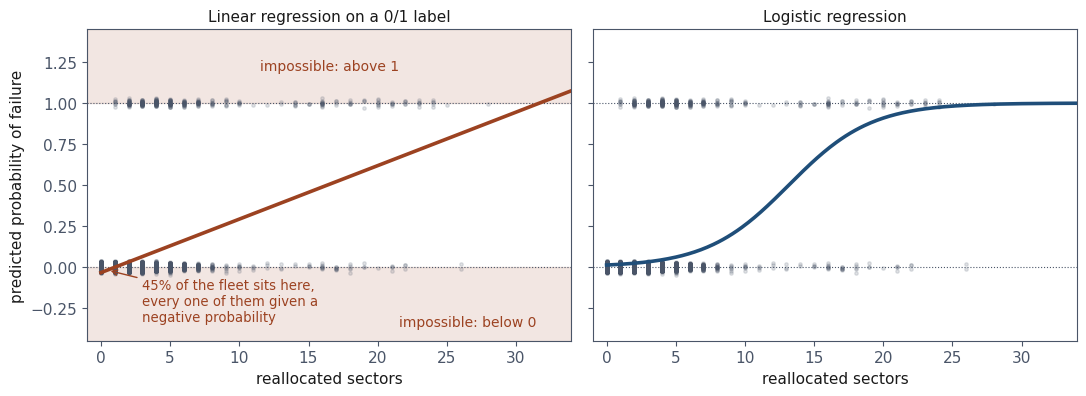

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


curve = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(x, y)
logistic_prediction = curve.predict_proba(grid)[:, 1]

jitter = np.random.default_rng(0).normal(0, .012, len(y))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), sharey=True)

for ax, prediction, title, colour in (
        (axes[0], linear_prediction, "Linear regression on a 0/1 label", RUST),
        (axes[1], logistic_prediction, "Logistic regression", BLUE)):
    ax.scatter(drives["reallocated_sectors"], y + jitter,
               s=6, alpha=.16, color=SLATE, zorder=1)
    ax.plot(grid["reallocated_sectors"], prediction, lw=2.6, color=colour, zorder=3)
    ax.axhline(0, color=SLATE, lw=.8, ls=":", zorder=2)
    ax.axhline(1, color=SLATE, lw=.8, ls=":", zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("reallocated sectors")
    ax.set_xlim(-1, 34)

axes[0].set_ylabel("predicted probability of failure")
axes[0].set_ylim(-0.45, 1.45)
for low, high in ((1.0, 1.45), (-0.45, 0.0)):
    axes[0].axhspan(low, high, color=RUST, alpha=.13, zorder=0)
axes[0].text(16.5, 1.20, "impossible: above 1", color=RUST, ha="center", fontsize=10)
axes[0].text(26.5, -0.36, "impossible: below 0", color=RUST, ha="center", fontsize=10)
axes[0].annotate("45% of the fleet sits here,\nevery one of them given a\nnegative probability",
                 xy=(0.5, -0.02), xytext=(3.0, -0.33), color=RUST, fontsize=9.5,
                 arrowprops=dict(arrowstyle="->", color=RUST))

fig.tight_layout()
fig.savefig(FIGURES / "linear_vs_logistic.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

The shaded bands on the left are the region where the straight line makes
claims that cannot be true. On the right the curve flattens as it approaches 0
and 1 and never leaves the interval.

**The intuition behind the shape.** The sigmoid is steep in the middle and flat
at the ends, and that is exactly the right behaviour. Going from 0 to 4
reallocated sectors should change your mind a great deal; going from 40 to 44
should barely register, because you had already concluded the drive was
finished. Evidence has diminishing returns, and the flat tails are what encodes
that.

## 2. Odds, log-odds, and what the coefficients mean

The sigmoid is not an arbitrary S-shaped curve. It is the inverse of the
**log-odds**, and that is what makes logistic regression interpretable.

The *odds* of an event are the probability that it happens divided by the
probability that it does not: a probability of 0.2 is odds of 0.25, or "1 to
4". Odds run from 0 to infinity, which is better than 0 to 1 but still
one-sided. Take the logarithm and you get a quantity that runs over the whole
real line — and that is what a linear model can safely predict.

So logistic regression is a **linear model of the log-odds**. The table makes
the correspondence concrete.

In [4]:
probabilities = np.array([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
table = pd.DataFrame({
    "probability": probabilities,
    "odds": probabilities / (1 - probabilities),
    "log-odds (z)": np.log(probabilities / (1 - probabilities)),
})
print(table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

print("\nsigmoid undoes the log-odds:")
print(f"  sigmoid(0)    = {sigmoid(0):.3f}   an even bet")
print(f"  sigmoid(-6.2) = {sigmoid(-6.2):.4f}  the intercept of our data")
print(f"  sigmoid(+2.2) = {sigmoid(2.2):.3f}")

 probability     odds  log-odds (z)
       0.010    0.010        -4.595
       0.100    0.111        -2.197
       0.250    0.333        -1.099
       0.500    1.000         0.000
       0.750    3.000         1.099
       0.900    9.000         2.197
       0.990   99.000         4.595

sigmoid undoes the log-odds:
  sigmoid(0)    = 0.500   an even bet
  sigmoid(-6.2) = 0.0020  the intercept of our data
  sigmoid(+2.2) = 0.900


Read the last two lines together, because they are the whole story of an
imbalanced problem. The drives in this fleet have an intercept of −6.2, so a
drive with perfectly average telemetry has a **0.2%** chance of failing. To
push that to a coin flip, the evidence has to move the log-odds by more than
six — and only badly degraded drives do that.

**A note on units.** A coefficient in logistic regression is a change in
log-odds per unit of the feature, so `exp(coefficient)` is a multiplier on the
odds. Our features are standardised first, so "one unit" means one standard
deviation: a coefficient of 1.80 says that a drive one standard deviation worse
on the sector counter has `exp(1.80)` ≈ 6.0 times the odds of failing. That is
the sentence to say out loud when someone asks what the model learned.

**Two cautions, because both are easy to get wrong.** Six times the *odds* is
not six times the *probability* — at these small probabilities the two are
close, but at large ones they are not: odds of 9 doubled is odds of 18, which
moves the probability only from 0.90 to 0.95. And the counters go through a
`log1p` before standardising, so the standard deviation is measured on the log
scale; one unit there is a multiplicative step in sectors, not an additive
one.

## 3. Why squared error is the wrong cost

The obvious move is to keep lesson 3's cost — squared error — and apply it to
the sigmoid's output. It is worth seeing why that fails, because the reason is
not "it scores a bit worse".

**The intuition.** Squared error puts a ceiling on how wrong you can be. If a
drive did fail and the model said 0.0001, the squared error is
$(1 - 0.0001)^2 \approx 1$ — barely more than the 0.25 it would have paid for
shrugging and saying 0.5. A cost function that treats a confident falsehood as
only four times worse than an honest "don't know" is not going to push hard
against confident falsehoods.

Log loss has no ceiling: that same prediction costs $-\log(0.0001) \approx 9.2$,
and the cost grows without bound as the model approaches certainty in the wrong
direction.

That difference in *cost* becomes a difference in *learning* through the
gradient, which is what the optimiser actually uses. Differentiating each loss
with respect to the log-odds $z$, for an example whose true label is 1:

$$\frac{\partial}{\partial z}(p-1)^2 = 2(p-1)\,p(1-p)
  \qquad\qquad
  \frac{\partial}{\partial z}\left[-\log p\right] = p - 1$$

The squared-error gradient carries a factor $p(1-p)$, which **goes to zero when
$p$ goes to zero** — precisely when the model is most confidently wrong. The log
loss gradient goes to $-1$ instead: maximum push, exactly where it is needed.
The figure shows both.

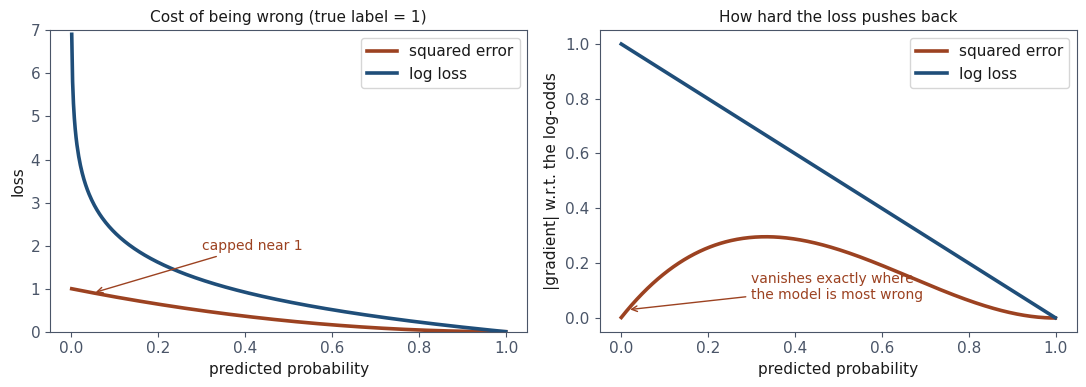

p = 0.5    squared error  0.250   log loss   0.693   |grad| squared  0.2500   |grad| log 0.500
p = 0.1    squared error  0.810   log loss   2.303   |grad| squared  0.1620   |grad| log 0.900
p = 0.01   squared error  0.980   log loss   4.605   |grad| squared  0.0196   |grad| log 0.990
p = 0.001  squared error  0.998   log loss   6.908   |grad| squared  0.0020   |grad| log 0.999


In [5]:
p = np.linspace(0.001, 0.999, 500)

# For an example whose true label is 1.
squared_loss = (p - 1) ** 2
log_loss_curve = -np.log(p)
squared_gradient = np.abs(2 * (p - 1) * p * (1 - p))
log_gradient = np.abs(p - 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].plot(p, squared_loss, lw=2.6, color=RUST, label="squared error")
axes[0].plot(p, log_loss_curve, lw=2.6, color=BLUE, label="log loss")
axes[0].set_ylim(0, 7)
axes[0].set_title("Cost of being wrong (true label = 1)", fontsize=11)
axes[0].set_xlabel("predicted probability"); axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].annotate("capped near 1", xy=(0.05, squared_loss[25]), xytext=(0.30, 1.9),
                 color=RUST, fontsize=10,
                 arrowprops=dict(arrowstyle="->", color=RUST))

axes[1].plot(p, squared_gradient, lw=2.6, color=RUST, label="squared error")
axes[1].plot(p, log_gradient, lw=2.6, color=BLUE, label="log loss")
axes[1].set_title("How hard the loss pushes back", fontsize=11)
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("|gradient| w.r.t. the log-odds")
axes[1].legend()
axes[1].annotate("vanishes exactly where\nthe model is most wrong",
                 xy=(0.015, 0.03), xytext=(0.30, 0.07), color=RUST, fontsize=10,
                 arrowprops=dict(arrowstyle="->", color=RUST))

fig.tight_layout()
fig.savefig(FIGURES / "loss_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

for probability in (0.5, 0.1, 0.01, 0.001):
    print(f"p = {probability:<6} squared error {(probability - 1) ** 2:6.3f}"
          f"   log loss {-np.log(probability):7.3f}"
          f"   |grad| squared {abs(2 * (probability - 1) * probability * (1 - probability)):7.4f}"
          f"   |grad| log {abs(probability - 1):5.3f}")

Read the last two columns of the printout. As the prediction slides from 0.5
down to 0.001 — the model going from undecided to confidently wrong — the log
loss gradient grows from 0.5 towards 1, while the squared-error gradient
collapses towards zero. **The wronger the model gets, the less squared error
asks it to change.**

That is the failure. It is not that squared error scores badly; it is that
squared error stops teaching.

So the cost function is not a matter of taste. The handout derives log loss from
**maximum likelihood** and shows it is not a clever choice at all, but the only
one consistent with the model we just wrote down — along with the fact, which
matters for the optimiser, that log loss is convex in the weights while squared
error composed with the sigmoid is not.

## 4. Gradient descent, in fifteen lines

The gradient of the log loss has the same shape as lesson 3's:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}
  \left(\hat{y}^{(i)} - y^{(i)}\right) x_j^{(i)}$$

The prediction error times the feature, averaged. **It is the identical
formula** — only $\hat{y}$ is now a sigmoid rather than a dot product. That
coincidence is not luck; the handout shows where it comes from, and it is one
of the tidiest results in the subject.

log loss: 0.6931 at the start -> 0.0692 after 4,000 iterations


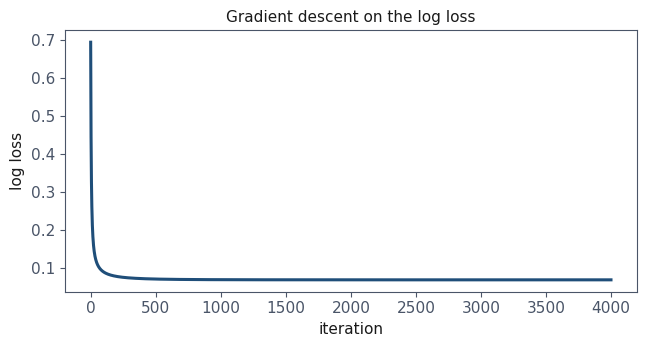

In [6]:
def fit_logistic(X, y, learning_rate=0.5, iterations=4_000):
    """Batch gradient descent on the log loss. Returns weights, bias, history."""
    m, n = X.shape
    w, b = np.zeros(n), 0.0
    history = []
    for _ in range(iterations):
        p = sigmoid(X @ w + b)
        history.append(-np.mean(y * np.log(p + 1e-12)
                                + (1 - y) * np.log(1 - p + 1e-12)))
        error = p - y
        w -= learning_rate * (X.T @ error) / m
        b -= learning_rate * error.mean()
    return w, b, np.array(history)


X_all = transform_features(drives)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, drives["failed"], test_size=0.25, random_state=42,
    stratify=drives["failed"])

scaler = StandardScaler().fit(X_train)
Z_train = scaler.transform(X_train)

w_scratch, b_scratch, history = fit_logistic(Z_train, y_train.to_numpy())

print(f"log loss: {history[0]:.4f} at the start -> {history[-1]:.4f} after "
      f"{len(history):,} iterations")

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(history, lw=2.2, color=BLUE)
ax.set_xlabel("iteration"); ax.set_ylabel("log loss")
ax.set_title("Gradient descent on the log loss", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "logloss_descent.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 5. The decision boundary

With two features the model can be drawn. The boundary is the set of points
where the predicted probability is exactly the threshold — by default 0.5,
which is the same as saying the log-odds are zero.

Because the log-odds are linear in the features, **that set is a straight
line**. Logistic regression is a linear classifier: the curve is in the
probabilities, not in the boundary.

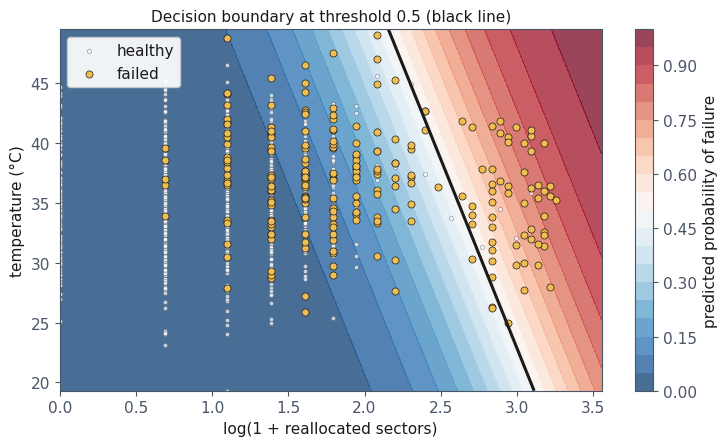

In [7]:
pair = ["reallocated_sectors", "temperature_c"]
two = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
two.fit(X_train[pair], y_train)

xx, yy = np.meshgrid(
    np.linspace(0, np.log1p(34), 320),
    np.linspace(X_all["temperature_c"].min(), X_all["temperature_c"].max(), 320))
probability = two.predict_proba(
    pd.DataFrame({pair[0]: xx.ravel(), pair[1]: yy.ravel()}))[:, 1]
probability = probability.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
shading = ax.contourf(xx, yy, probability, levels=np.linspace(0, 1, 21),
                      cmap="RdBu_r", alpha=.75)
ax.contour(xx, yy, probability, levels=[0.5], colors=[INK], linewidths=2.2)

healthy = X_train[y_train == 0].sample(900, random_state=1)
failed = X_train[y_train == 1]
ax.scatter(healthy[pair[0]], healthy[pair[1]], s=9, color="white",
           edgecolor=SLATE, linewidth=.4, label="healthy", alpha=.7)
ax.scatter(failed[pair[0]], failed[pair[1]], s=26, color=GOLD,
           edgecolor=INK, linewidth=.5, label="failed")

ax.set_xlabel("log(1 + reallocated sectors)"); ax.set_ylabel("temperature (°C)")
ax.set_title("Decision boundary at threshold 0.5 (black line)", fontsize=11)
ax.legend(loc="upper left", framealpha=.92)
fig.colorbar(shading, ax=ax, label="predicted probability of failure")
fig.tight_layout()
fig.savefig(FIGURES / "decision_boundary.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Two things to notice, and the second is the one that matters for the rest of
the lesson.

**The boundary is straight**, as promised, and tilted: both features push in
the same direction, sectors much harder than temperature.

**Almost every gold point is on the blue side of the line.** At a threshold of
0.5 this model declares nearly the whole fleet healthy, including most of the
drives that failed. It is not a broken model — the probabilities are good, as
the next section shows. It is a badly chosen *threshold*, and telling those two
failures apart is what notebooks 2 and 3 are about.

## 6. The same model from scikit-learn, and the truth

One line replaces the fifteen. Then the part that is only possible with
synthetic data: comparing what we estimated against what actually generated the
labels.

In [8]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000))
model.fit(X_train, y_train)

comparison = pd.DataFrame({
    "true": list(TRUE_COEFFICIENTS.values()),
    "from scratch": w_scratch,
    "scikit-learn": model[-1].coef_[0],
}, index=FEATURES)
comparison["odds multiplier"] = np.exp(comparison["scikit-learn"])

print(comparison.round(3).to_string())
print(f"\nintercept   true {TRUE_INTERCEPT:+.2f}   "
      f"from scratch {b_scratch:+.2f}   "
      f"scikit-learn {model[-1].intercept_[0]:+.2f}")

                     true  from scratch  scikit-learn  odds multiplier
reallocated_sectors  1.80         1.685         1.664            5.279
spin_retry_count     1.15         1.179         1.170            3.221
read_error_rate      0.85         0.880         0.871            2.389
temperature_c        0.45         0.472         0.465            1.591
power_on_hours       0.35         0.382         0.380            1.462
seek_error_rate      0.00         0.024         0.024            1.025

intercept   true -6.20   from scratch -6.14   scikit-learn -6.09


Three things worth pausing on.

**The estimates are close to the truth.** Reallocated sectors was generated
with a coefficient of 1.80 and recovered at about 1.66; spin retries 1.15
against 1.17; temperature 0.45 against 0.46. Nothing here is exact, because
6,000 drives carrying 230 failures is a modest amount of evidence — but the
ordering and the magnitudes are right.

**The hand-written version agrees with the library.** Same problem, same
answer. The fifteen lines were not a toy.

**The decoy was caught.** `seek_error_rate` was generated with a coefficient of
exactly zero — it is a real-looking counter with no connection to failure — and
the model estimates it at about 0.02, an odds multiplier of 1.02. The model did
not fall for it. Notebook 3 asks the harder question: would you have noticed if
you had not been told?

## What to take away

- A linear model on a 0/1 label predicts values that are not probabilities. The
  **sigmoid** fixes that by modelling the **log-odds** linearly.
- `exp(coefficient)` is a **multiplier on the odds** — the sentence to use when
  explaining a fitted model to someone who did not fit it.
- **Log loss, not squared error.** Squared error composed with the sigmoid is
  non-convex and nearly flat where the model is confidently wrong, so gradient
  descent stalls exactly where it should be learning.
- The gradient is `(prediction − truth) × feature`, **identical in form** to
  linear regression.
- The decision boundary is a **straight line**, and the threshold that defines
  it is a **choice you make**, not a property of the model.

That last point is where notebook 2 starts: at a threshold of 0.5 this model
misses more than a third of the drives that fail, and is still 97.7% accurate.
Both of those numbers are true, and one of them is useless.